#  <center> Taller  de Aprendizaje Automático </center>
##  <center> Taller 5: Estimación de la demanda de bicicletas compartidas utilizando *Neural Networks*.  </center>

# Introducción

En esta actividad se retomará el problema de la competencia [*Bike Sharing Demand*](https://www.kaggle.com/c/bike-sharing-demand) visto en el Taller 3.
Esta vez las estimaciónes deben obtenerse utilizando la herramienta: *Multilayer Perceptron* (MLP). Es importante mantener la función *Root Mean Squared Logarithmic Error* (RMSLE) como medida de desempeño de manera de poder comparar los resultados con los obtenidos en el Taller 3.

Tanto las preguntas teóricas como la parte práctica de esta actividad están ligadas al contenido del capítulo 10 (*Introduction to
Artificial Neural Networks with
Keras*) del libro del curso.


## Objetivos


*   Trabajar con modelos MLP utilizando la librería [*Keras*](https://keras.io/api/).
*   Probar algunas de las herramientas disponibles para la busqueda de hiperparámetros.
*   Interpretar modelos con *Shapley Values*.

## Formas de trabajo

#### Opción 1: Trabajar localmente

##### Descarga de datos disponibles en Kaggle

Luego, para descargar el dataset de Demanda de Bicicletas:

In [1]:
!kaggle competitions download -c bike-sharing-demand

bike-sharing-demand.zip: Skipping, found more recently modified local copy (use --force to force download)


Descomprima el archivo descargado:

In [2]:
import shutil
shutil.unpack_archive('./bike-sharing-demand.zip', './')

In [3]:
#Importar mis cosas
from sklearn.compose import TransformedTargetRegressor
from sklearn.pipeline import Pipeline
import joblib  # Para guardar el modelo
from sklearn.model_selection import train_test_split
import tensorflow as tf
import keras_tuner as kt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from scikeras.wrappers import KerasClassifier
import shap

## Paquetes a utilizar

En esta actividad se utilizarán algunas bibliotecas auxiliares que deberán ser instaladas. Ejecutar la siguiente celda hasta que se ejecute sin errores. En caso de error, se puede instalar el paquete faltante desde el notebook con el comando:

`!pip install paquete_faltante`

In [4]:
#import comet_ml in the top of your file
from comet_ml import Experiment
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
#import seaborn as sns
#sns.set_theme(style="whitegrid")

df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')
df_submission = pd.read_csv('sampleSubmission.csv')

## Parte 1 - Procesamiento de los datos

Dado que ya se ha familiarizado con los datos, se implementa el mismo preprocesamiento que utilizó en el Taller 3.

In [5]:
#Preprocesamiento de ellos:

df_train['datetime'] = pd.to_datetime(df_train['datetime'])

df_train['hour'] = df_train['datetime'].dt.hour
df_train['weekday'] = df_train['datetime'].dt.weekday
df_train['month'] = df_train['datetime'].dt.month 
df_train['year'] = df_train['datetime'].dt.year

y_train_full = df_train['count']
df_train = df_train.drop(['datetime', 'casual', 'registered', 'count'], axis=1) # hay que eliminarlas ya que tiene relación directa con la columna objetivo y no aparecen en el conjunto de *test*.

- Dado que se trabajará con redes neuronales, ¿Cree conveniente realizar alguna modificación en el preprocesamiento?

#### Respuesta:

Si, para poder entrar cualquier regresor necesitamos de un conjunto de validación. El de test se da como dato pero el de validación tenemos que partirlo nosotros. Porque para el Taller usamos CV y en ese caso la validación está incluida en el proceso pero para este caso tenemos que dividir el conjunto de train. 

In [6]:
# Dejo la normalizacion para la primer capa de la red, ahora encode las caracteristicas.

num_attribs = ["temp", "atemp", "humidity", "windspeed"]
cat_attribs = ["season", "holiday", "workingday", "weather", "hour", "weekday", "month", "year"]

# Me creo pipelines distintos para las distintas categorias
cat_pipeline = Pipeline([
    ("imp_cat",SimpleImputer(strategy="most_frequent")),
    ("ohe",OneHotEncoder(handle_unknown='ignore')),
])

num_pipeline = Pipeline([
    ("imp_num",SimpleImputer(strategy="most_frequent")),
    ("scaler",StandardScaler()),
])

# Me creo el ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("cat",cat_pipeline,cat_attribs),
        ("num",num_pipeline, num_attribs),
    ])

In [7]:
X_train_full, X_val_full, y_train, y_val = train_test_split(df_train,y_train_full, test_size=0.1, random_state=42)

In [8]:
X_train_full = preprocessor.fit_transform(X_train_full)
X_val_full = preprocessor. transform(X_val_full)

## Parte 2 - Multilayer Perceptron (MLP)

Siguiendo el ejemplo de la sección *Building a Regression MLP Using the Sequential API*:


*   Implementar un estimador manteniendo los hiperparámetros del ejemplo.
*   ¿Cuál es la cantidad total de parámetros entrenables de la red?
*   Seleccionar aleatoriamente un *10%* de los datos para validación, y graficar la función de *loss* (*Mean Squared Logarithmic Error*) de entrenamiento y validación.

***Nota:** Observe que en el ejemplo se agrega una capa de normalización*

In [9]:
tf.random.set_seed(42)
# Construir el modelo
model = tf.keras.Sequential([
    # Capas ocultas
    tf.keras.layers.Dense(50, activation="relu"),
    tf.keras.layers.Dense(50, activation="relu"),
    tf.keras.layers.Dense(50, activation="relu"),
    # Capa de salida
    tf.keras.layers.Dense(1)
])

# Compilar el modelo con RMSLE como pérdida
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
model.compile(loss="mean_squared_logarithmic_error", optimizer=optimizer, metrics=["MeanSquaredLogarithmicError"])

# Entrenar el modelo
history = model.fit(X_train_full, y_train, epochs=20, validation_data=(X_val_full, y_val))

# Evaluar el modelo en el conjunto de prueba
mse_test, rmse_test = model.evaluate(X_val_full, y_val)

y_pred = model.predict(X_train_full)

Epoch 1/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - MeanSquaredLogarithmicError: 8.3525 - loss: 8.3525 - val_MeanSquaredLogarithmicError: 1.2967 - val_loss: 1.2967
Epoch 2/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 818us/step - MeanSquaredLogarithmicError: 1.0684 - loss: 1.0684 - val_MeanSquaredLogarithmicError: 0.4917 - val_loss: 0.4917
Epoch 3/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 800us/step - MeanSquaredLogarithmicError: 0.4288 - loss: 0.4288 - val_MeanSquaredLogarithmicError: 0.3006 - val_loss: 0.3006
Epoch 4/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 805us/step - MeanSquaredLogarithmicError: 0.2812 - loss: 0.2812 - val_MeanSquaredLogarithmicError: 0.2236 - val_loss: 0.2236
Epoch 5/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 800us/step - MeanSquaredLogarithmicError: 0.2100 - loss: 0.2100 - val_MeanSquaredLogarithmicError: 0.1727 - val_loss: 0.1727
Epoch 6/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 801us/step - MeanSquaredLogarithmicError: 0.1649 - loss: 0.1649 - val_MeanSquaredLogarithmicError: 0.1426 - val_loss: 0

MSE en conjunto de validación: 0.075717993080616
RMSE en conjunto de validación: 0.075717993080616


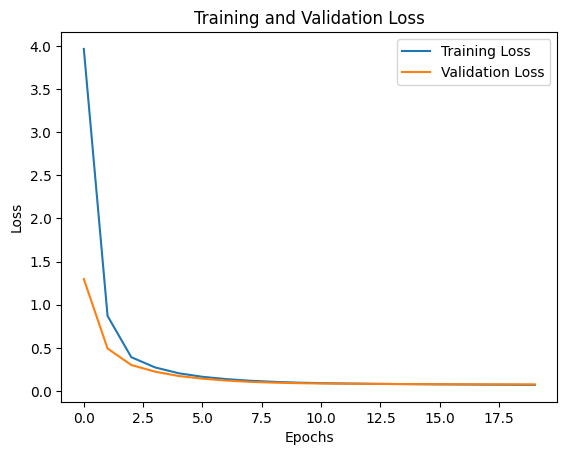

In [10]:
#Mostrar los resultados del entrenamiento:
print("MSE en conjunto de validación:", mse_test)
print("RMSE en conjunto de validación:", rmse_test)

# Obtener la pérdida y la pérdida de validación del historial
loss = history.history['loss']
val_loss = history.history['val_loss']

# Crear un gráfico de la pérdida con respecto a las épocas
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

## Parte 3 - Ajuste fino

Siguiendo el ejemplo de la sección *Fine-Tuning Neural Network Hyperparameters*:


*   Utilizar la herramienta *RandomSearch* de *KerasTuner* para la busqueda de hiperparámetros del modelo implementado en *keras*. 
*   Probar el *tip* que se sugiere en la sección *Number of Neurons per Hidden Layer* y comentar los resultados.

In [11]:
def build_model(hp):
    tf.random.set_seed(42)
    n_hidden = hp.Int("n_hidden", min_value=0, max_value=8, default=2)
    n_neurons = hp.Int("n_neurons", min_value=16, max_value=256)
    learning_rate = hp.Float("learning_rate", min_value=1e-4, max_value=1e-2, sampling="log")
    optimizer = hp.Choice("optimizer", values=["sgd", "adam"])
    if optimizer == "sgd":
        optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)
    else:
        optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Flatten())
    for _ in range(n_hidden):
        model.add(tf.keras.layers.Dense(n_neurons, activation="relu"))
    model.add(tf.keras.layers.Dense(1, activation="linear"))
    model.compile(loss="mean_squared_logarithmic_error", optimizer=optimizer)
    return model


In [12]:
random_search_tuner = kt.RandomSearch(
    build_model, objective="val_loss", max_trials=5, overwrite=True,)
random_search_tuner.search(X_train_full, y_train, epochs=20,
                           validation_data=(X_val_full, y_val))

Trial 5 Complete [00h 00m 14s]
val_loss: 0.07717477530241013

Best val_loss So Far: 0.07717477530241013
Total elapsed time: 00h 00m 58s


In [14]:
# Mejor modelo
top3_models = random_search_tuner.get_best_models(num_models=3)
best_model = top3_models[0]

# Mejores hiperparámetros
top3_params = random_search_tuner.get_best_hyperparameters(num_trials=3)
top3_params[0].values  

{'n_hidden': 3,
 'n_neurons': 229,
 'learning_rate': 0.0004786436065027085,
 'optimizer': 'adam'}

In [15]:
#Ajustamos los datos al mejor modelo:
best_model.fit(X_train_full, y_train, epochs=10)
test_loss = best_model.evaluate(X_val_full, y_val)

Epoch 1/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0512
Epoch 2/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0479
Epoch 3/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0459
Epoch 4/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0441
Epoch 5/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0425
Epoch 6/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0409
Epoch 7/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0393
Epoch 8/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0377
Epoch 9/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0363
Epoch 10/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0349
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 708us/step - loss: 0.0780


In [16]:
ruta_modelo_entrenado = "mejor_modelo_entrenado.h5"
best_model.save(ruta_modelo_entrenado)

In [17]:
print("RMSE en conjunto de validación:", test_loss)

RMSE en conjunto de validación: 0.0809415727853775


## Parte 4 - Ajuste fino (Optuna)

*   Utilizar *Optuna* para la busqueda de hiperparámetros del modelo en *Keras*. Se le sugiere seguir uno de los siguientes ejemplos: [*keras_simple*](https://github.com/optuna/optuna-examples/blob/main/keras/keras_simple.py),  [OptunaSearchCV](https://github.com/optuna/optuna-examples/blob/main/sklearn/sklearn_optuna_search_cv_simple.py).

***Nota:** Optuna puede utilizarse para optimizar otras técnicas por fuera de las redes neuronales.*

***Nota2:** Keras Tuner permite realizar Optimización bayesiana.*

In [27]:
import sklearn_optuna_search_cv_simple

In [ ]:
def build_model(trial):
    n_hidden = trial.suggest_int("n_hidden", 0, 8)
    n_neurons = trial.suggest_int("n_neurons", 16, 256)
    learning_rate = trial.suggest_loguniform("learning_rate", 1e-4, 1e-2)
    optimizer_name = trial.suggest_categorical("optimizer", ["sgd", "adam"])

    if optimizer_name == "sgd":
        optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)
    else:
        optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Flatten())
    for _ in range(n_hidden):
        model.add(tf.keras.layers.Dense(n_neurons, activation="relu"))
    model.add(tf.keras.layers.Dense(1, activation="linear"))
    model.compile(loss="mean_squared_logarithmic_error", optimizer=optimizer, metrics=["accuracy"])
    return model


def objective(trial):
    model = build_model(trial)

    # Train the model
    model.fit(X_train_full, y_train, epochs=20, validation_data=(X_val_full, y_val), verbose=0)

    # Evaluate the model on the validation set
    loss, accuracy = model.evaluate(X_val_full, y_val, verbose=0)

    # Optuna aims to minimize the objective value, so negate the accuracy
    return -accuracy

if __name__ == "__main__":
    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=20)

    print("Best trial:")
    trial = study.best_trial

    print("  Value: ", -trial.value)  # Negate back to get accuracy
    print("  Params: ")
    for key, value in trial.params.items():
        print("    {}: {}".format(key, value))


## Parte 5 - Pipeline



*   Incorporar el estimador con mejor desempeño a un *pipeline* similar al implementado en el taller 3. Puede ser útil la librería [scikeras](https://adriangb.com/scikeras/stable/migration.html).
*   Subir los resultados de los datos *test* a la página de la competencia.



In [18]:
# Define tu pipeline
pipeline_NN = Pipeline([
    ('preprocessor', preprocessor),
    ('best_model', best_model)  
])

In [19]:
df_test = pd.read_csv('test.csv')
df_test_original = pd.read_csv('test.csv')
df_submission = pd.read_csv('sampleSubmission.csv')

# Asegurarse de que df_test es procesado de la misma forma que df_train
df_test['datetime'] = pd.to_datetime(df_test['datetime'])
df_test['day'] = df_test['datetime'].dt.day
df_test['month'] = df_test['datetime'].dt.month
df_test['year'] = df_test['datetime'].dt.year
df_test['hour'] = df_test['datetime'].dt.hour
df_test['weekday'] = df_test['datetime'].dt.weekday


# Ahora elimina la columna 'datetime' de df_test, ya que no se usa en el entrenamiento
df_test = df_test.drop(['datetime'], axis=1)

# Entrena tu pipeline con el mejor modelo obtenido
best_model.fit(X_train_full, y_train, epochs=10)

# Añade el mejor modelo a tu pipeline
y_pred = pipeline_NN.predict(df_test)

Epoch 1/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0335
Epoch 2/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0328
Epoch 3/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0316
Epoch 4/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0306
Epoch 5/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0298
Epoch 6/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0305
Epoch 7/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0276
Epoch 8/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0273
Epoch 9/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0264
Epoch 10/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0261
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [24]:
y_pred = y_pred.reshape((y_pred.shape[0],))

In [25]:
#Guardo el archivo submission.csv
# Suponemos que tienes acceso al DataFrame original de test con la columna 'datetime'
# Si lo has eliminado, asegúrate de tener alguna forma de reconstruirlo o mantenerlo para el submission
df_submission = pd.DataFrame({
    'datetime': df_test_original['datetime'],  # Asegúrate de utilizar el df original antes de eliminar 'datetime'
    'count': y_pred  # Usamos las predicciones directamente
})

# Asegurarte de que las predicciones no tengan valores negativos
df_submission['count'] = df_submission['count'].clip(lower=0)

# Guardar el DataFrame a un archivo CSV
df_submission.to_csv('submission.csv', index=False)

# Muestra las primeras filas para verificar
print(df_submission.head())

              datetime      count
0  2011-01-20 00:00:00  11.051112
1  2011-01-20 01:00:00   4.301490
2  2011-01-20 02:00:00   1.933628
3  2011-01-20 03:00:00   3.458891
4  2011-01-20 04:00:00   3.004534


In [23]:
df_test = pd.read_csv('test.csv')
df_submission = pd.read_csv('sampleSubmission.csv')

df_test['datetime'] = pd.to_datetime(df_test['datetime'])

df_test['hour'] = df_test['datetime'].dt.hour
df_test['weekday'] = df_test['datetime'].dt.weekday
df_test['month'] = df_test['datetime'].dt.month
df_test['year'] = df_test['datetime'].dt.year
# df_test['year'] = (df_test['year'] == 2011).astype(int)


## Parte 6 - Shapley Values

- Siguiendo el [ejemplo](https://shap.readthedocs.io/en/latest/example_notebooks/overviews/An%20introduction%20to%20explainable%20AI%20with%20Shapley%20values.html) presentado en la sección *Explaining a non-additive boosted tree model* de la librería *shap*. Encuentre los shapley values para el mejor modelo que haya encontrado.
- Elija una muestra y mediante la función *shap.plots.waterfall* observe la explicación de la predicción del modelo.

Más explicación de los Shapley Values y su uso en la interpretabilidad de modelos de aprendizaje automático se puede encontrar [aquí](https://christophm.github.io/interpretable-ml-book/shapley.html).

In [686]:
# Fecha y hora específica
X100 = shap.utils.sample(X_train_full, 100) 
date_time = "2011-04-24 17:00:00"
# Filtrar la fila que corresponde a la fecha y hora específica
specific_instance = df_test[df_test['datetime'] == date_time]

In [687]:
# Create a list of column names
column_names = ['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed', 'hour', 'weekday', 'month', 'year']

# Assuming X_train_full has the correct number of columns (13) for the desired DataFrame
X100_ = pd.DataFrame(X100, columns=column_names)

In [688]:
specific_instance = specific_instance.drop(['datetime'], axis = 1)

In [689]:
# Create SHAP explainer with specific instance (assuming single row DataFrame)
explainer_best_model = shap.Explainer(best_model, X100_)

# Calculate Shapley Values for the specific instance
shap_values_specific_instance = explainer_best_model(specific_instance)

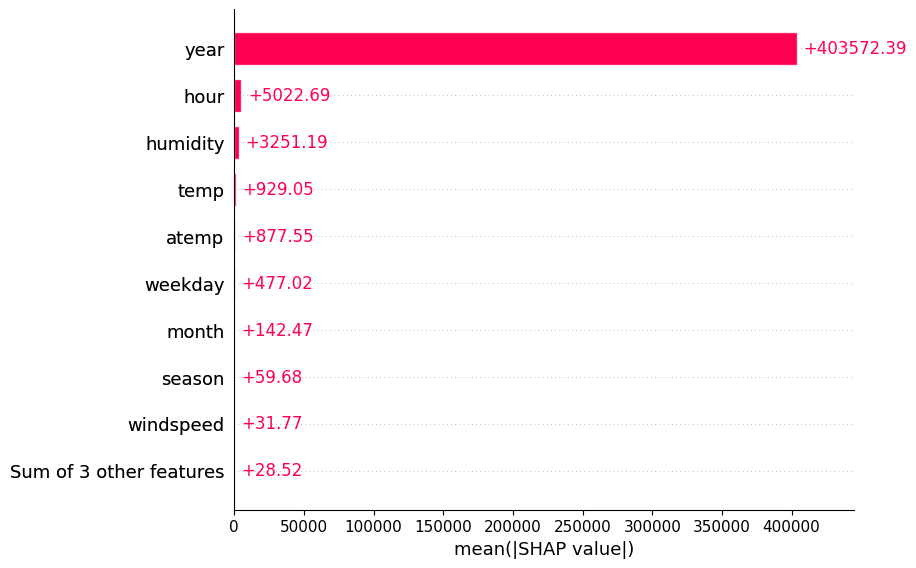

In [690]:
# Ploteo teniendo en cuenta el año:
shap.plots.bar(shap_values_specific_instance)

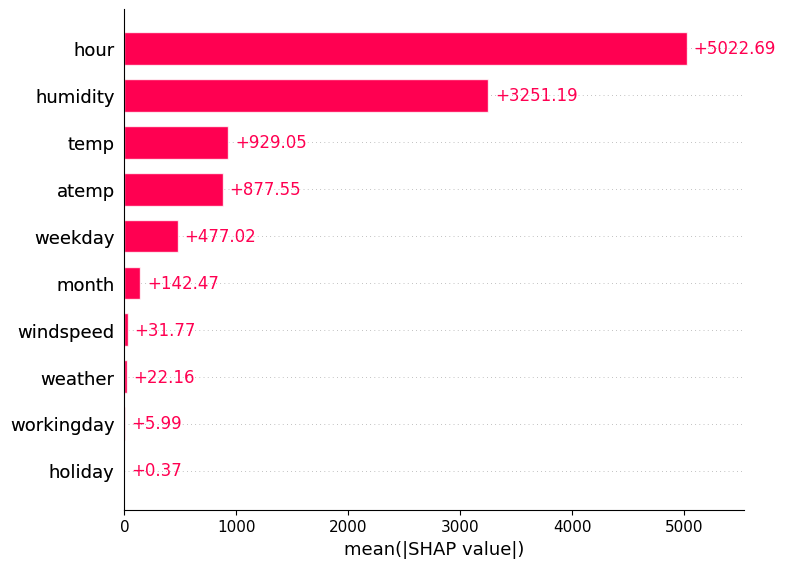

In [691]:
#Ploteo teniendo en cuenta que el año no nos da suficiente información para lo que necesitamos:
# Exclude first and last feature using advanced indexing
shap_values_excl_first_last = shap_values_specific_instance[:, 1:-1]

# Create the bar plot with the sliced values
shap.plots.bar(shap_values_excl_first_last)
